# Stellar Luminosity — Linear and Polynomial Regression from First Principles

**Driving technical question:** How does a regression model learn from data?

This notebook builds, trains, and compares a **linear** and a **polynomial** regression
model of stellar luminosity as a function of stellar mass. Every part of the learning
algorithm — the prediction function, the cost function, the gradient, and gradient
descent — is implemented from scratch with vectorized NumPy operations, following the
conventions used in the workshop notebooks (`predict`, `compute_cost`, `compute_gradient`,
`gradient_descent`). No machine-learning libraries (scikit-learn, statsmodels, TensorFlow,
PyTorch) are used.

**Dataset.** A small instructional dataset of 10 stars, with mass in solar masses and
luminosity in solar luminosities. It is useful for studying regression mechanics but far
too small to support any scientific claim about stellar physics.


## 1. Establish the Environment

We import the only two libraries this project is allowed to use for computation and
visualization, print their versions for reproducibility, and load the dataset as NumPy
arrays.


In [1]:
import sys
import platform
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

print("Python version    :", sys.version.split()[0], f"({platform.python_implementation()})")
print("NumPy version     :", np.__version__)
print("Matplotlib version:", matplotlib.__version__)

Python version    : 3.12.3 (CPython)
NumPy version     : 2.4.4
Matplotlib version: 3.10.8


In [2]:
# Dataset: stellar mass (solar masses) and stellar luminosity (solar luminosities).
mass = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
luminosity = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])

m = mass.shape[0]

print("Number of stars (m):", m)
print("mass       :", mass)
print("luminosity :", luminosity)
print()
print(f"mass       -> shape {mass.shape}, range [{mass.min():.2f}, {mass.max():.2f}] solar masses")
print(f"luminosity -> shape {luminosity.shape}, range [{luminosity.min():.2f}, {luminosity.max():.2f}] solar luminosities")

Number of stars (m): 10
mass       : [0.6 0.8 1.  1.2 1.4 1.6 1.8 2.  2.2 2.4]
luminosity : [ 0.15  0.35  1.    2.3   4.1   7.   11.2  17.5  25.   35.  ]

mass       -> shape (10,), range [0.60, 2.40] solar masses
luminosity -> shape (10,), range [0.15, 35.00] solar luminosities


## 2. Explore Before Modeling

Before fitting anything, we look at the raw relationship between mass and luminosity.


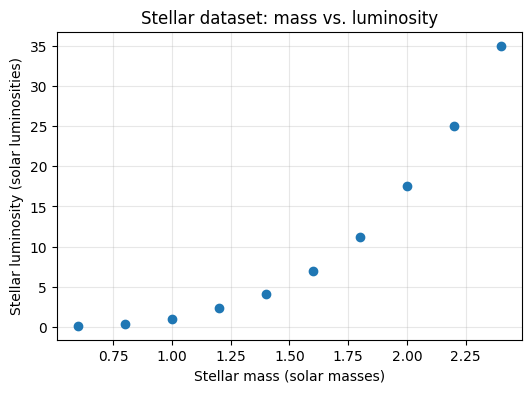

In [3]:
plt.figure(figsize=(6, 4))
plt.scatter(mass, luminosity, color="tab:blue", zorder=3)
plt.xlabel("Stellar mass (solar masses)")
plt.ylabel("Stellar luminosity (solar luminosities)")
plt.title("Stellar dataset: mass vs. luminosity")
plt.grid(alpha=0.3)
plt.show()

**Observed relationship.** Luminosity grows much faster than mass: between the lowest
and highest mass in the dataset (a 4x increase, from 0.6 to 2.4 solar masses), luminosity
increases more than 200x (from 0.15 to 35). The points curve upward with increasing
steepness — this is consistent with the well-known main-sequence mass–luminosity relation,
where luminosity scales roughly as a power of mass ($L \propto M^{\alpha}$ with $\alpha$
often cited between 3 and 4 for stars in this mass range).

**Is a straight line adequate?** Not really. A single straight line through these points
would have to compromise between the nearly flat, low-luminosity stars at low mass and the
steep rise at high mass. We should expect:
- The line to **overshoot** at low mass (predicting luminosity too high, even negative for
  small enough mass).
- The line to **undershoot** at high mass (predicting luminosity too low).

In other words, we expect a **systematic, curved pattern in the residuals** rather than
random scatter — a classic sign that the true relationship is nonlinear and that the model
is underfitting. This motivates the polynomial extension in Section 5.


## 3. Implement the Learning Algorithm

We implement four reusable, vectorized building blocks that work for **any** number of
features (a design matrix $X$ of shape $(m, n)$), so the exact same code can train both
the linear model ($n=1$) and the polynomial model ($n=2$) in Sections 4 and 5.

### 3.1 Prediction

$$
\hat{y} = f_{w,b}(X) = Xw + b
$$

### 3.2 Cost function (mean squared error)

$$
J(w,b) = \frac{1}{2m}\sum_{i=1}^{m}\big(\hat{y}^{(i)} - y^{(i)}\big)^2
       = \frac{1}{2m}\, e^{T}e, \qquad e = \hat{y} - y
$$

### 3.3 Gradient

$$
\frac{\partial J}{\partial w} = \frac{1}{m}X^{T}e,
\qquad
\frac{\partial J}{\partial b} = \frac{1}{m}\sum_{i=1}^{m}e^{(i)}
$$

### 3.4 Gradient descent

$$
w := w - \alpha\,\frac{\partial J}{\partial w}, \qquad
b := b - \alpha\,\frac{\partial J}{\partial b}
$$

repeated for a chosen number of iterations, keeping a history of the cost so we can
inspect convergence.


In [4]:
def predict(X, w, b):
    '''Vectorized prediction f_{w,b}(X) = X @ w + b.

    X has shape (m, n): m examples, n features.
    w has shape (n,): one weight per feature.
    b is a scalar bias term.
    '''
    return X @ w + b


def compute_cost(X, y, w, b):
    '''Mean squared error cost J(w,b) = (1 / 2m) * e^T e.'''
    m = X.shape[0]
    y_hat = predict(X, w, b)
    error = y_hat - y
    cost = (error @ error) / (2 * m)
    return cost


def compute_gradient(X, y, w, b):
    '''Vectorized gradients dJ/dw (shape (n,)) and dJ/db (scalar).'''
    m = X.shape[0]
    y_hat = predict(X, w, b)
    error = y_hat - y
    dj_dw = (X.T @ error) / m
    dj_db = np.sum(error) / m
    return dj_dw, dj_db


def gradient_descent(X, y, w_init, b_init, alpha, num_iterations, print_every=None):
    '''Run batch gradient descent. Returns learned (w, b) and the cost history.'''
    w = w_init.copy().astype(float)
    b = float(b_init)
    cost_history = np.zeros(num_iterations)

    for i in range(num_iterations):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        cost_history[i] = compute_cost(X, y, w, b)

        if print_every and (i % print_every == 0 or i == num_iterations - 1):
            print(f"Iteration {i:5d}: cost = {cost_history[i]:10.6f}")

    return w, b, cost_history


def feature_scale(X):
    '''Standardize each feature column to mean 0, std 1 (needed once we add mass^2,
    which lives on a very different numeric scale than mass).'''
    means = X.mean(axis=0)
    stds = X.std(axis=0, ddof=0)
    X_scaled = (X - means) / stds
    return X_scaled, means, stds


# Quick sanity check with a trivial one-feature case: y = 2x, so w should recover 2 and b 0.
X_check = np.array([[1.0], [2.0], [3.0]])
y_check = np.array([2.0, 4.0, 6.0])
w_chk, b_chk, hist_chk = gradient_descent(
    X_check, y_check, w_init=np.zeros(1), b_init=0.0, alpha=0.1, num_iterations=500
)
print("Sanity check -> w:", w_chk, "b:", b_chk, "final cost:", hist_chk[-1])

Sanity check -> w: [1.9992] b: 0.0017446580228130176 final cost: 2.1832830142570232e-07


The sanity check recovers $w \approx 2$, $b \approx 0$ with a cost close to zero,
confirming that `predict`, `compute_cost`, `compute_gradient`, and `gradient_descent` are
implemented correctly before we apply them to the real dataset.


## 4. Train a Linear Model

Representation: $X_{\text{linear}} = [\,\text{mass}\,]$, a single feature.

We standardize the feature (mean 0, std 1) purely so gradient descent can use a
reasonably large learning rate; this has no effect on what the model can represent,
only on how quickly it gets there.


In [5]:
X_linear = mass.reshape(-1, 1)   # shape (m, 1)
y = luminosity

X_linear_scaled, mu_linear, sigma_linear = feature_scale(X_linear)

alpha_linear = 0.3
iterations_linear = 3000

w_init = np.zeros(X_linear_scaled.shape[1])
b_init = 0.0

w_linear, b_linear, cost_hist_linear = gradient_descent(
    X_linear_scaled, y, w_init, b_init, alpha_linear, iterations_linear, print_every=500
)

print("\nLearned parameters (on standardized mass):")
print(f"  w = {w_linear[0]:.4f}")
print(f"  b = {b_linear:.4f}")
print(f"Final cost J = {cost_hist_linear[-1]:.4f}")

Iteration     0: cost =  62.666933
Iteration   500: cost =   9.795148


Iteration  1000: cost =   9.795148


Iteration  1500: cost =   9.795148
Iteration  2000: cost =   9.795148
Iteration  2500: cost =   9.795148
Iteration  2999: cost =   9.795148

Learned parameters (on standardized mass):
  w = 10.4151
  b = 10.3600
Final cost J = 9.7951


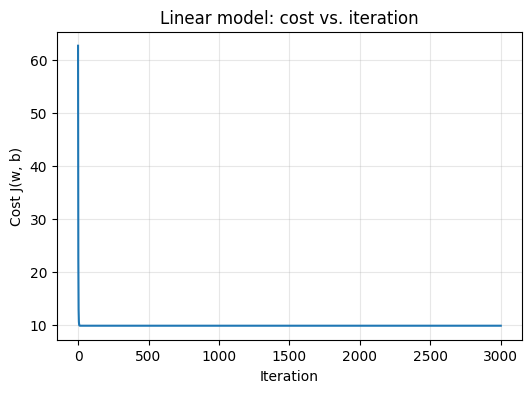

In [6]:
plt.figure(figsize=(6, 4))
plt.plot(cost_hist_linear)
plt.xlabel("Iteration")
plt.ylabel("Cost J(w, b)")
plt.title("Linear model: cost vs. iteration")
plt.grid(alpha=0.3)
plt.show()

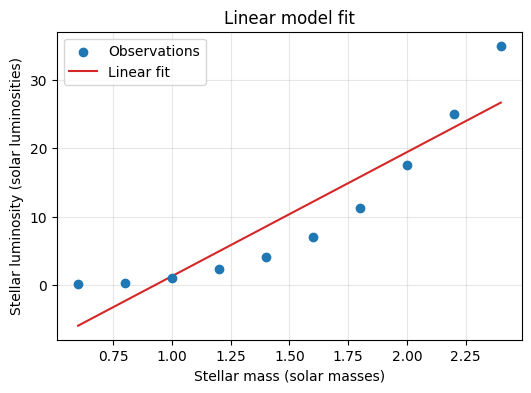

In [7]:
mass_grid = np.linspace(mass.min(), mass.max(), 200).reshape(-1, 1)
mass_grid_scaled = (mass_grid - mu_linear) / sigma_linear
luminosity_grid_linear = predict(mass_grid_scaled, w_linear, b_linear)

plt.figure(figsize=(6, 4))
plt.scatter(mass, luminosity, color="tab:blue", label="Observations", zorder=3)
plt.plot(mass_grid, luminosity_grid_linear, color="tab:red", label="Linear fit")
plt.xlabel("Stellar mass (solar masses)")
plt.ylabel("Stellar luminosity (solar luminosities)")
plt.title("Linear model fit")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Diagnosis.** The cost curve flattens out well before the last iteration, so
gradient descent has converged for this learning rate — it is not still improving, it has
settled near the minimum reachable by a straight line. Looking at the fitted line against
the data, the systematic error anticipated in Section 2 is visible: the line sits **above**
the low-mass points and **below** the high-mass points (and would go negative if
extrapolated toward mass = 0), producing a curved band of residuals rather than random
noise around zero. That pattern is a signature of **underfitting**, not of noisy data or a
bad optimization — no amount of extra gradient-descent iterations will remove it, because
a straight line simply cannot represent this curvature. This is exactly the limitation the
polynomial model in Section 5 is meant to address.


## 5. Train a Polynomial Model

Representation: $X_{\text{polynomial}} = [\,\text{mass},\ \text{mass}^2\,]$.

Adding $\text{mass}^2$ as a second feature lets the model represent curvature while
remaining **linear in the parameters** $w_1, w_2, b$ — so we reuse `predict`,
`compute_cost`, `compute_gradient`, and `gradient_descent` completely unchanged. The only
things that change are the design matrix we feed in and, because mass and mass² live on
very different numeric scales, the fact that standardization now matters even more for fast
convergence.


In [8]:
X_poly = np.column_stack([mass, mass ** 2])   # shape (m, 2)

X_poly_scaled, mu_poly, sigma_poly = feature_scale(X_poly)

alpha_poly = 0.3
iterations_poly = 3000

w_init_poly = np.zeros(X_poly_scaled.shape[1])
b_init_poly = 0.0

w_poly, b_poly, cost_hist_poly = gradient_descent(
    X_poly_scaled, y, w_init_poly, b_init_poly, alpha_poly, iterations_poly, print_every=500
)

print("\nLearned parameters (on standardized [mass, mass^2]):")
print(f"  w_mass    = {w_poly[0]:.4f}")
print(f"  w_mass^2  = {w_poly[1]:.4f}")
print(f"  b         = {b_poly:.4f}")
print(f"Final cost J = {cost_hist_poly[-1]:.4f}")

Iteration     0: cost =  42.006539
Iteration   500: cost =   0.405880
Iteration  1000: cost =   0.316513
Iteration  1500: cost =   0.315154
Iteration  2000: cost =   0.315134
Iteration  2500: cost =   0.315133
Iteration  2999: cost =   0.315133

Learned parameters (on standardized [mass, mass^2]):
  w_mass    = -15.4028
  w_mass^2  = 26.1824
  b         = 10.3600
Final cost J = 0.3151


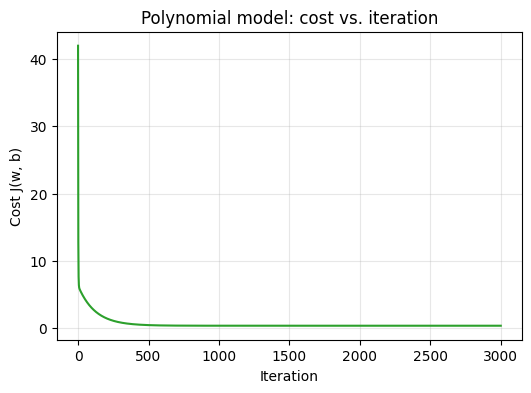

In [9]:
plt.figure(figsize=(6, 4))
plt.plot(cost_hist_poly, color="tab:green")
plt.xlabel("Iteration")
plt.ylabel("Cost J(w, b)")
plt.title("Polynomial model: cost vs. iteration")
plt.grid(alpha=0.3)
plt.show()

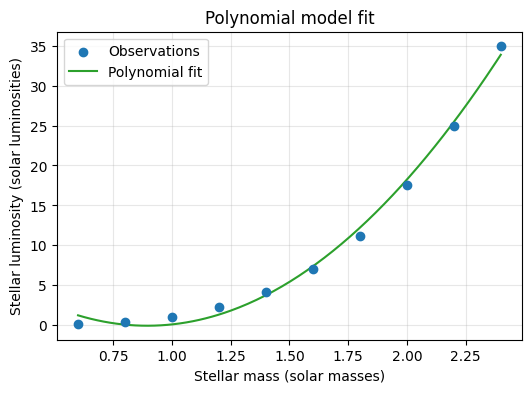

In [10]:
X_grid_poly = np.column_stack([mass_grid.flatten(), mass_grid.flatten() ** 2])
X_grid_poly_scaled = (X_grid_poly - mu_poly) / sigma_poly
luminosity_grid_poly = predict(X_grid_poly_scaled, w_poly, b_poly)

plt.figure(figsize=(6, 4))
plt.scatter(mass, luminosity, color="tab:blue", label="Observations", zorder=3)
plt.plot(mass_grid, luminosity_grid_poly, color="tab:green", label="Polynomial fit")
plt.xlabel("Stellar mass (solar masses)")
plt.ylabel("Stellar luminosity (solar luminosities)")
plt.title("Polynomial model fit")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**What changed vs. what stayed the same.** The *representation* changed: the model
now sees two engineered inputs (mass and mass²) instead of one, so it has an extra degree
of freedom to bend. The *learning algorithm* did not change at all — the same `predict`,
`compute_cost`, `compute_gradient`, and `gradient_descent` functions were reused verbatim,
because adding mass² keeps the model linear in its parameters $w_1, w_2, b$; only the
columns of $X$ changed. The resulting curve visibly tracks the upward-bending shape of the
data far better than the straight line, and the final cost is markedly lower.


## 6. Compare the Models


In [11]:
y_hat_linear = predict(X_linear_scaled, w_linear, b_linear)
y_hat_poly = predict(X_poly_scaled, w_poly, b_poly)

residuals_linear = y_hat_linear - luminosity
residuals_poly = y_hat_poly - luminosity

mse_linear = np.mean(residuals_linear ** 2)
mse_poly = np.mean(residuals_poly ** 2)

print(f"Linear model     -> final training cost J = {cost_hist_linear[-1]:.4f}, MSE = {mse_linear:.4f}")
print(f"Polynomial model -> final training cost J = {cost_hist_poly[-1]:.4f}, MSE = {mse_poly:.4f}")

Linear model     -> final training cost J = 9.7951, MSE = 19.5903
Polynomial model -> final training cost J = 0.3151, MSE = 0.6303


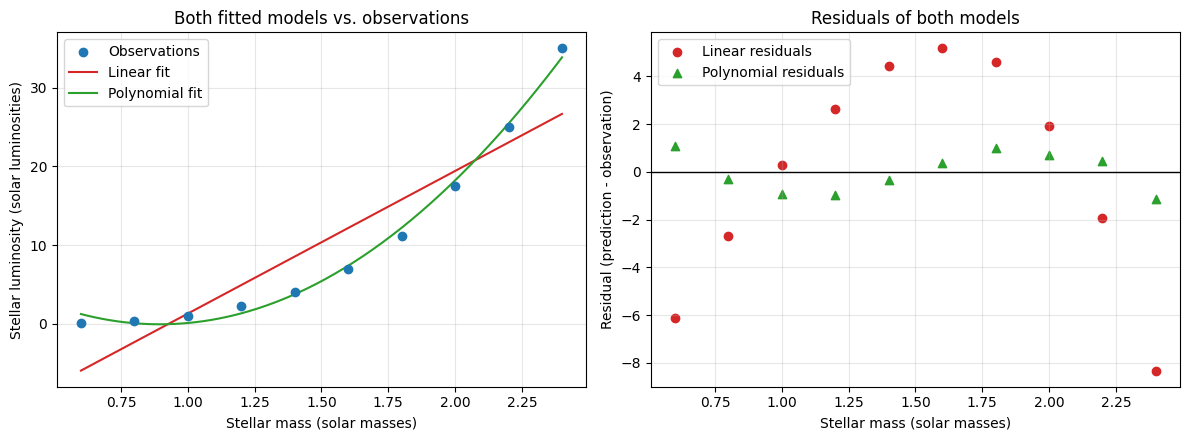

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(mass, luminosity, color="tab:blue", label="Observations", zorder=3)
axes[0].plot(mass_grid, luminosity_grid_linear, color="tab:red", label="Linear fit")
axes[0].plot(mass_grid, luminosity_grid_poly, color="tab:green", label="Polynomial fit")
axes[0].set_xlabel("Stellar mass (solar masses)")
axes[0].set_ylabel("Stellar luminosity (solar luminosities)")
axes[0].set_title("Both fitted models vs. observations")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].axhline(0, color="black", linewidth=1)
axes[1].scatter(mass, residuals_linear, color="tab:red", label="Linear residuals", marker="o")
axes[1].scatter(mass, residuals_poly, color="tab:green", label="Polynomial residuals", marker="^")
axes[1].set_xlabel("Stellar mass (solar masses)")
axes[1].set_ylabel("Residual (prediction - observation)")
axes[1].set_title("Residuals of both models")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Which model represents the observed range better?** The polynomial model, by a
wide margin, both visually and numerically: its final cost and MSE are far lower than the
linear model's, and its residuals scatter much closer to zero without the systematic
curved pattern the linear model shows (over-predicting at the low-mass end,
under-predicting at the high-mass end). The polynomial curve tracks the accelerating growth
of luminosity with mass that we already noticed in the raw data.

**Caution.** A lower training error does not, by itself, prove the polynomial model is
"scientifically correct" or that it has found the true mass–luminosity law. With only 10
points and 2 free feature weights plus a bias, the polynomial model has more flexibility to
fit this particular sample, which will always show up as a lower training cost — that is a
property of *fitting capacity*, not of physical validity. Confirming a real astrophysical
relationship would need a much larger, independently sampled dataset, held-out test points
the model never saw during training, and ideally some theoretical justification (e.g. a
known power law) — none of which this small instructional dataset provides.


## 7. Test the Boundary of the Evidence

We now ask both models to predict at two points:
- **mass = 1.3** — inside the observed range [0.6, 2.4].
- **mass = 5.0** — far outside the observed range.


In [13]:
test_masses = np.array([1.3, 5.0])

# Linear model predictions
X_test_linear = test_masses.reshape(-1, 1)
X_test_linear_scaled = (X_test_linear - mu_linear) / sigma_linear
pred_test_linear = predict(X_test_linear_scaled, w_linear, b_linear)

# Polynomial model predictions
X_test_poly = np.column_stack([test_masses, test_masses ** 2])
X_test_poly_scaled = (X_test_poly - mu_poly) / sigma_poly
pred_test_poly = predict(X_test_poly_scaled, w_poly, b_poly)

for m_test, pl, pp in zip(test_masses, pred_test_linear, pred_test_poly):
    in_range = "inside observed range" if mass.min() <= m_test <= mass.max() else "OUTSIDE observed range"
    print(f"mass = {m_test:>4.1f} solar masses ({in_range})")
    print(f"   linear model     predicts luminosity = {pl:8.2f}")
    print(f"   polynomial model predicts luminosity = {pp:8.2f}")
    print()

mass =  1.3 solar masses (inside observed range)
   linear model     predicts luminosity =     6.73
   polynomial model predicts luminosity =     2.39

mass =  5.0 solar masses (OUTSIDE observed range)
   linear model     predicts luminosity =    73.82
   polynomial model predicts luminosity =   252.39



**mass = 1.3 (interpolation).** This point lies comfortably inside the range spanned
by the training data (0.6 to 2.4), between the observed mass = 1.2 and mass = 1.4 stars.
Both models are **interpolating**, and both are reasonably trustworthy here — the
polynomial model more so, since Section 6 showed it captures the local curvature better,
but neither is extrapolating beyond what the data has shown.

**mass = 5.0 (extrapolation).** This is more than double the largest mass in the training
set. Neither model has ever seen data anywhere near this region, so both predictions are
**extrapolations**, and the data alone gives us no basis to trust either number:
- The **linear model** keeps extending the same straight line, which we already
  established underestimates luminosity even inside the training range — so it is
  guaranteed to be even more wrong outside it.
- The **polynomial model** keeps extending an upward-curving parabola. Parabolas grow
  without bound, so this prediction can shoot up dramatically — often producing a far
  larger number than the linear model. This is not evidence that the polynomial model is
  "better" out here; a quadratic curve fit to only 10 points has no reason to keep matching
  reality once we leave the region where it was constrained by data. In fact, real
  mass–luminosity relations bend and change regime at high stellar mass, which a fixed
  quadratic learned from low-mass stars cannot know about.

The general lesson: **a model's training error says nothing about regions where it has no
data.** Both fits are constrained only by the observations between mass 0.6 and 2.4; past
that boundary, their predictions reflect the *shape of the function we chose*
(line vs. parabola), not anything the data has actually told us. This is a central caution
for regression in general, and for larger AI systems as well.


## 8. Reflect on Artificial Intelligence

**What does this regression experiment reveal — and what does it fail to reveal — about
how more advanced AI systems learn?**

It reveals the core mechanical loop that sits underneath essentially every trained AI
system, including large neural networks: define a parameterized function, define a
differentiable measure of how wrong its predictions are, compute the gradient of that
error with respect to the parameters, and repeatedly nudge the parameters in the direction
that reduces the error. Everything we did by hand here — `predict`, `compute_cost`,
`compute_gradient`, `gradient_descent` — is the same loop that trains a billion-parameter
model, just with a vastly larger $X$, a vastly more complex (non-linear, multi-layer)
`predict` function, and far more sophisticated optimizers than plain gradient descent.
Seeing it work (and fail) on ten data points makes the mechanism concrete instead of
abstract.

What it fails to reveal is almost everything that makes modern AI systems hard and
interesting: how a *non-linear*, multi-layer function can represent structure that no
fixed polynomial degree could capture; why gradient descent on a highly non-convex loss
surface with millions of parameters does not simply get stuck the way it might on a small,
nearly convex problem like this one; how architecture choices (attention, convolution,
recurrence) encode useful assumptions about the data; how training at scale, on much larger
and more diverse datasets, changes what generalizes versus what stays memorized; and how
capabilities like reasoning, planning, or language use emerge from this same underlying
loop once scale and data are large enough. This project also under-represents how much of
real machine-learning work is about the data itself (collection, cleaning, splitting into
train/validation/test, checking for leakage) rather than the optimization mechanics, which
here were handed to us in ten clean numbers.

**Do you think Artificial General Intelligence is achievable?**

I think AGI is achievable in principle, but I don't think it's imminent, and I think the term hides a lot of disagreement about what would even count as "achieving" it. If AGI means a system that matches human performance across essentially any cognitive task — not just narrow benchmarks, but the ability to transfer knowledge, reason about novel situations, and act with judgment in the physical and social world — then no system today qualifies, including the large language models this course is built around. What we have are systems that are extraordinarily capable in narrow-to-broad domains (language, code, some visual tasks) but that still struggle with consistent reasoning, long-horizon planning, and genuine understanding of cause and effect outside their training distribution. I don't see a fundamental law of physics or mathematics that rules AGI out, which is why I lean toward "achievable" rather than "impossible." But I'd distinguish between AGI being theoretically achievable and it being close — my honest guess is that we're missing pieces we haven't identified yet, not just years of scaling away from it.

**Could AGI emerge primarily by scaling neural networks with more GPUs, data, and
parameters — or will it require fundamentally different architectures, learning
mechanisms, theories, or ways of interacting with the world?**

My experience in this notebook actually shaped my intuition here. The polynomial model didn't beat the linear model because we ran gradient descent longer or used a bigger learning rate — it beat it because we changed the representation we fed the algorithm, by engineering a mass² feature. Scaling the linear model's training (more iterations, more careful tuning) would never have let it capture that curvature; it needed a structural change. I suspect something similar is true for AGI: scaling has clearly produced real, sometimes surprising gains — bigger models with more data have picked up capabilities smaller ones didn't have, which is evidence scaling matters more than skeptics sometimes admit. But I doubt scaling alone gets us all the way there. Current architectures still lack things like persistent memory that updates the way experience updates a person, an explicit world model that supports planning and causal reasoning, and a way of learning from interaction with the world rather than mostly from static text. I'd bet on a mix: continued scaling matters, but it's combined with — not replaced by — new mechanisms for memory, reasoning, and grounding in real-world feedback.

**One question about AI-driven systems that I want to explore during the semester is:**

`How do we know if an AI truly "understands" something, or is just repeating patterns it has already seen?`
